<p style="align: center;"><img align=center src="https://drive.google.com/uc?export=view&id=1aS4vX-ucDKBmZmZMrBwgjl_DvLAadX2C" width=900/></p>


<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

# Домашнее задание. RAG.

В этом домашнем задании вам предстоит создать туристический RAG, провести EDA и проявить креатив! :)

Вам дан набор данных, содержащий информацию о памятниках, архитектуре и других значимых местах. В данных есть:
* название достопримечательности;
* идентификатор на WikiData;
* город расположения;
* координаты долготы и широты;
* описание (извлеченное из WikiData);
* изображение в формате base64;
* сгенерированное описание изображения (генерация с помощью модели BLIP).

Некоторые из памятников могут встречаться несколько раз, но с различными изображениями, из которых не все могут быть качественными. Для компенсации этого даны текстовые описания.

Часть данных взята с Национальной технологической олимпиады студентов по CV. Базовое решение предполагает использование мультимодального ru-CLIP. Но в данном домашнем задании предлагается решить эту задачу творчески, используя NLP подход.

## Установка и импорт библиотек

In [1]:
#!pip install -q gdown torch transformers transformers accelerate bitsandbytes langchain sentence-transformers faiss-cpu openpyxl datasets langchain-community ragatouille umap-learn

In [2]:
#pip install langchain==0.0.352 langchain-community==0.0.10 ragatouille==0.0.9

In [3]:
import os
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

import torch
import gc

# Очистка при старте
gc.collect()
torch.cuda.empty_cache()

In [4]:
import gdown
import pandas as pd
from tqdm.notebook import tqdm
from typing import Optional, List, Tuple
import matplotlib.pyplot as plt
from langchain_core.documents import Document as LangchainDocument
from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer
from langchain_community.vectorstores import FAISS
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores.utils import DistanceStrategy
import numpy as np
import plotly.express as px
from transformers import pipeline
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from ragatouille import RAGPretrainedModel

#------------------------------------------------------------------------------------
# from langchain.text_splitter import ... # выберите другую стратегию разбивки на чанки

pd.set_option("display.max_colwidth", None)

In [5]:
#!pip install spacy
#!python -m spacy download ru_core_news_sm
#Раз нельзя использовать RecursiveTextSplitter, можно взять SpacyTextSplitter.

In [6]:
from langchain.text_splitter import SpacyTextSplitter

## Загрузка данных (4 балла)

In [7]:
# url = 'https://drive.google.com/uc?id=1P1BsvI2jPN3fEqjc2YZxmQ-MTs22WVUk'
# output = 'file.csv'

# gdown.download(url, output, quiet=False)



In [8]:
data = pd.read_csv('file.csv')

In [9]:
pd.set_option("display.max_colwidth", 12)
data.sample(15)

,Unnamed: 0,Name,WikiData,City,Lon,Lat,description,image,en_txt
388,388,Свято-Тр...,Q4463552,Екатерин...,60.614399,56.827347,Троицкий...,/9j/4AAQ...,arafed c...
14431,4169,Ярославс...,Q16723452,Ярославль,39.895737,57.674446,Ярославс...,/9j/4AAQ...,there ar...
14374,4112,Ярославс...,Q4538877,Ярославль,39.867222,57.636250,Ярославс...,/9j/4AAQ...,people a...
14085,3823,Церковь ...,Q16715792,Ярославль,39.895622,57.622604,Правосла...,/9j/4AAQ...,arafed i...
446,446,Художест...,Q16714939,Екатерин...,60.603756,56.831680,музей в ...,/9j/4AAQ...,woman st...
4385,1159,Благовещ...,Q4087775,Нижний Н...,43.976471,56.322552,монастыр...,/9j/4AAQ...,arafed g...
10139,3643,Надвратн...,NaN,Владимир,40.413509,56.131752,NaN,/9j/4AAQ...,arafed y...
2506,2564,улица До...,Q15954283,Екатерин...,60.603172,56.834320,улица в ...,/9j/4AAQ...,there is...
229,229,Театр кукол,Q4227893,Екатерин...,60.610809,56.839527,кинотеат...,/9j/4AAQ...,arafed g...
2759,2985,Уральски...,Q1938341,Екатерин...,60.654282,56.844051,бывшее н...,/9j/4AAQ...,arafed v...


Для декодирования изображений, закодированных в формате base64, можно использовать следующий код:

In [10]:
import base64
import requests
import matplotlib.pyplot as plt
from PIL import Image
import PIL
from io import BytesIO

In [11]:
def get_image(data):
  image = Image.open(BytesIO(base64.b64decode(data))).convert('RGB')
  return image

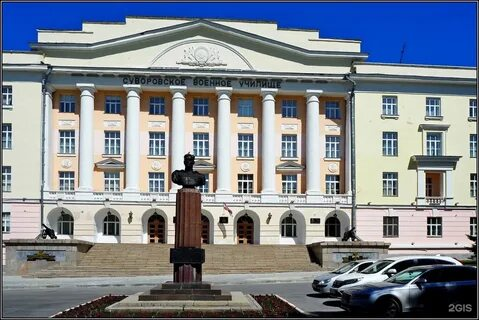

In [12]:
get_image(data.sample(1)['image'].tolist()[0])

В данных есть выбросы — записи, не относящихся к туристическим или историческим объектам. Для очистки данных можно, например, использовать алгоритм TF-IDF: создаем корпус текстов из описаний, применяем TF-IDF, извлекаем наиболее редко или часто встречающиеся слова. Они могут указывать на мусорные данные, такие как мемы, баннеры или личные фото людей. После выделения подозрительных паттернов, можно провести ручную проверку и фильтрацию данных.

Для дальнейшего тестирования и получения чистых сэмплов, рекомендуется взять не менее 100 чистых образцов со стратификацией по городу и названию места. Это можно сделать, выбрав случайным образом несколько образцов из каждой категории (город + название места), чтобы обеспечить равномерное представительство и разнообразие данных.

**!! Важно:** Помните, что чистые сэмплы одного и того же места выдадут примерно одинаковое описание. Есть несколько стратегий, как повысить разнообразие ответов:

- выбор одного самого лучшего:
  - самое длинное описание
  - смое подходящие по мнению LLM
- конкатенация описаний (но важно не сконкатенировать слишком много)

Изображения можно отдать в мета-данные.

In [13]:
# Сначала мы посмотрим на записи датасета, в которых нет описаний. 
# Возможно, информация из этих строк может оказаться полезной, если только там
# есть фото, широта, долгота или вдруг название города. Так что сначала проверим это

In [14]:
no_desc = data[data['description'].isnull()]
with_desc = data[data['description'].notnull()]
len(with_desc[(
    with_desc['City'].isnull() |
    with_desc['Lon'].isnull() |
    with_desc['Lat'].isnull() |
    with_desc['image'].isnull() |
    with_desc['WikiData'].isnull()
)])

0

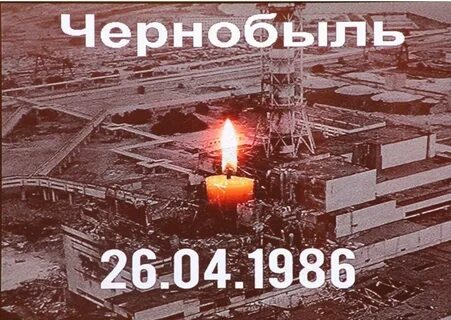

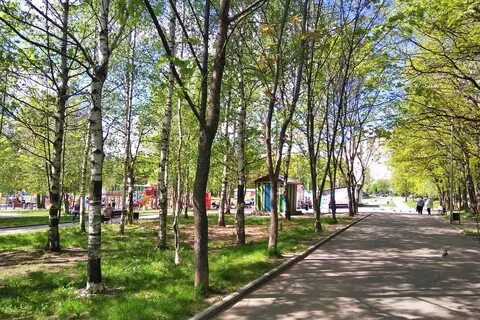

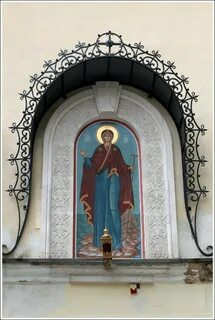

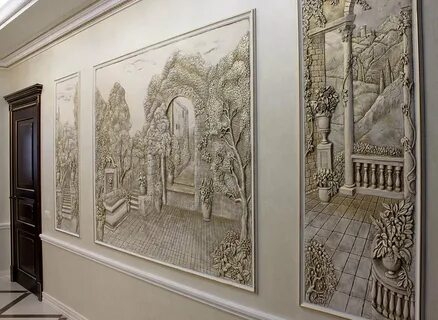

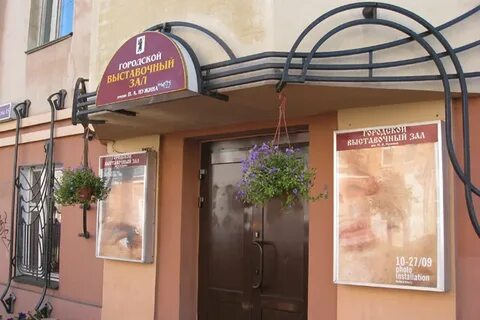

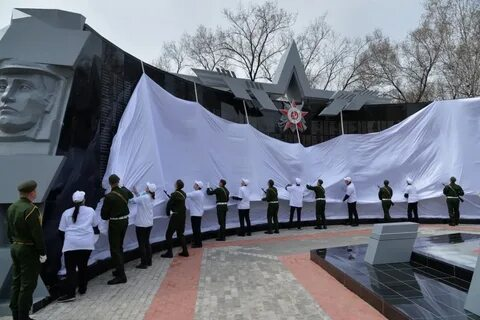

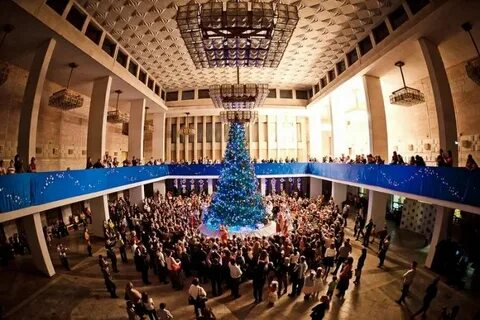

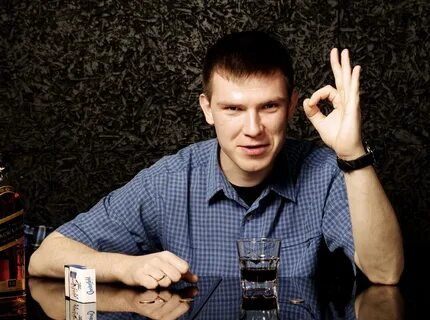

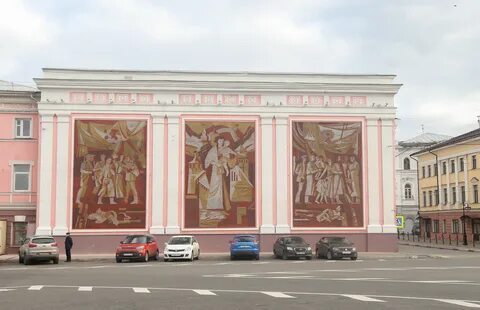

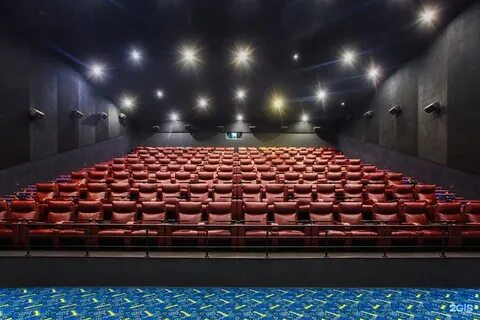

In [246]:
for row in no_desc['image'].sample(10):
    img = get_image(row)
    display(img)
    

In [16]:
#Мы можем увидеть, что в картинках, что относятся к записям без описания, нет ничего
# ценного, и напротив, много мусора, включая фото людей, какие-то случайные картинки и тд.
# Так что разумно просто не использовать их и далее использовать только те строки, где
# описание есть

In [17]:
df = with_desc.drop('Unnamed: 0', axis = 1)

In [18]:
df.info()

<class 'pandas.DataFrame'>
Index: 12078 entries, 0 to 14633
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Name         12078 non-null  str    
 1   WikiData     12078 non-null  str    
 2   City         12078 non-null  str    
 3   Lon          12078 non-null  float64
 4   Lat          12078 non-null  float64
 5   description  12078 non-null  str    
 6   image        12078 non-null  str    
 7   en_txt       12078 non-null  str    
dtypes: float64(2), str(6)
memory usage: 534.0 MB


In [19]:
print(f'уникальных викидат {df['WikiData'].nunique()}')
print(f'уникальных названий {df['Name'].nunique()}')
print(f'уникальных lon {df['Lon'].nunique()}')
print(f'уникальных lat {df['Lat'].nunique()}')

уникальных викидат 296
уникальных названий 317
уникальных lon 320
уникальных lat 322


In [20]:
# Не совсем понятно, но наверное, лучше всего использовать как уникальный идентификатор
# объекта всё-таки строку викидата. Названия могут отличаться из-за больших и маленьких
# букв или каких-то разниц в названии, когда один и тот же объект называется немного
# по-разному. Широта и долгота могут отличаться из-за того что указывают на разные входы в
# музей. А вот викидата выглядит достаточно надёжным признаком! На её основании мы и 
# будем приводить датасет к единой форме для поиска RAG. Колонку en_txt можно выбросить.
# Она описывает картинки, и мне кажется, описания там не очень помогут задаче. Картинки 
# мы на всякий случай объединим в список, чтобы их не терять

In [21]:
df = df.drop('en_txt', axis = 1)

In [22]:
df['desc_len'] = df['description'].str.len()

df = df.sort_values('desc_len', ascending=False)

df_grouped = df.groupby('WikiData').agg({
    'Name': lambda x: x.value_counts().idxmax(),
    'City': lambda x: x.value_counts().idxmax(),
    'Lon': 'mean',
    'Lat': 'mean',
    'description': 'first',
    'image': lambda x: list(x),
}).reset_index()
df=df_grouped
df

,WikiData,Name,City,Lon,Lat,description,image
0,Q100270892,Нижегоро...,Нижний Н...,44.005554,56.327255,историче...,[/9j/4AA...
1,Q100701435,Гарнизон...,Нижний Н...,44.004299,56.327614,здание в...,[/9j/4AA...
2,Q100882660,Губернат...,Нижний Н...,44.005272,56.329803,парк в Н...,[/9j/4AA...
3,Q104554178,Церковь ...,Ярославль,39.834522,57.609947,Правосла...,[/9j/4AA...
4,Q104776528,Церковь ...,Нижний Н...,44.072117,56.318909,Спасо-Пр...,[/9j/4AA...
...,...,...,...,...,...,...,...
291,Q97999957,Здание У...,Нижний Н...,44.021175,56.325153,Здание У...,[/9j/4AA...
292,Q98381215,Дом архи...,Нижний Н...,44.009949,56.329483,Жилой до...,[/9j/4AA...
293,Q99522676,Рекорд,Нижний Н...,44.004810,56.323887,Общежити...,[/9j/4AA...
294,Q99622643,Дворец в...,Нижний Н...,44.003147,56.327217,админист...,[/9j/4AA...


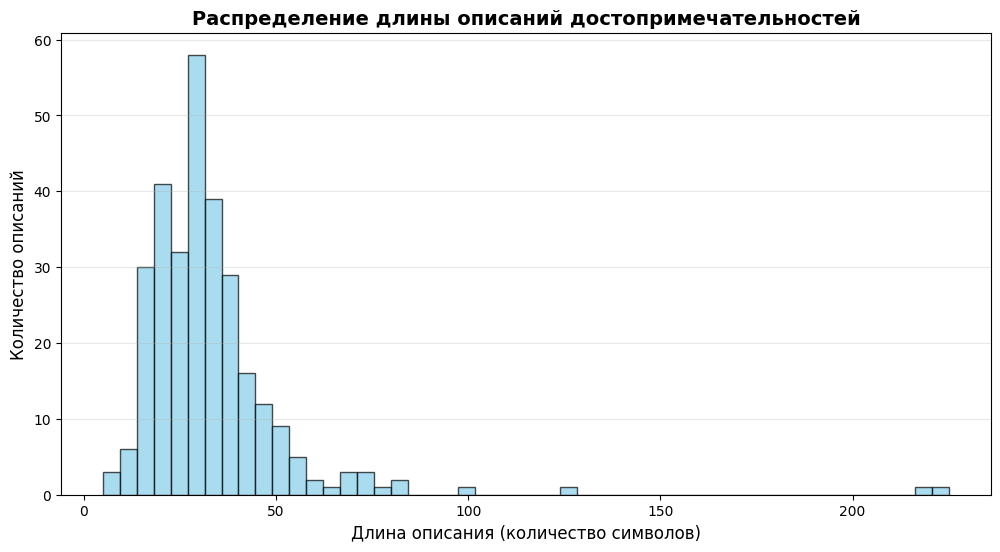

In [23]:
df['desc_length'] = df['description'].str.len()

plt.figure(figsize=(12, 6))
plt.hist(df['desc_length'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Распределение длины описаний достопримечательностей', fontsize=14, fontweight='bold')
plt.xlabel('Длина описания (количество символов)', fontsize=12)
plt.ylabel('Количество описаний', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.show()

In [24]:
# То есть, как можно увидеть, у нас очень-очень много очень коротких описаний. Длинных 
# же и подробных всего парочка

In [25]:
pd.set_option("display.max_colwidth", None)
print(f'Всего записей с длиной меньше 20 символов: {len(df[df['desc_length']<20])}')
df[df['desc_length']<20]['description'].sample(5)

Всего записей с длиной меньше 20 символов: 47


127               Дом муз
218      храм в Ярославле
96     Автозаводский парк
195      Храм в Ярославле
182         Парк Кулибина
Name: description, dtype: str

In [26]:
df = df.drop('desc_length', axis = 1)

In [27]:
# Нужно объединить описание, город, название в единый текст, а картинки сохранить
# в метаданные. И город, имя, широту, долготу, викидату тоже. Потому что как видно
# выше, описания очень мало чтобы модель сгенерировала какой-то приличный ответ,
# пусть у неё будет больше информации

In [28]:
documents = []
for _, row in df.iterrows():

    full_text = f"Название: {row['Name']}, Город: {row['City']}, Описание: {row['description']}"
    
    # Создаём документ для RAG
    doc = LangchainDocument(
        page_content=full_text,  
        metadata={               
            "image": row['image'],
            "description": row['description'],
            "name": row['Name'],
            "city": row['City'],
            "lon": row['Lon'],
            "lat": row['Lat'],
            "wikidata": row['WikiData']
        }
    )
    documents.append(doc)
print(f'всего записей {len(documents)}')

всего записей 296


Здесь предлагаем вам построить RAG с использованием моделей, которые не были представлены на семинаре (включая другие векторные базы данных). Можно воспользоваться материалами по этой ссылке: [data_connection/vectorstores](https://python.langchain.com/v0.1/docs/modules/data_connection/vectorstores/).

!Важно, не забудьте отранжировать чанки текстов с помощью `ragatouille`. На практике порядок текстов в промпте влияет на точность ответа.

In [29]:
#Теперь нужно сделать эмбеддинги. Возьмём не ту модель, что в семинаре, 
# как надо по условию
model_name = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"

embeddings = HuggingFaceEmbeddings(
    model_name=model_name,
    model_kwargs={"device": "cpu"},
    encode_kwargs={"normalize_embeddings": True}
)

/mnt/kurama/python/Akatsuki_Always/lib/python3.12/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [30]:
# Теперь чанки

text_splitter = SpacyTextSplitter(
    pipeline="ru_core_news_sm", 
    chunk_size=500,
    chunk_overlap=50
)

chunks = text_splitter.split_documents(documents)

print(f"Всего документов было: {len(documents)}")
print(f"Всего чанков стало: {len(chunks)}")
print(f"Пример чанка: {chunks[16].page_content}...")

Всего документов было: 296
Всего чанков стало: 296
Пример чанка: Название: Памятник Я.М. Свердлову, Город: Екатеринбург, Описание: памятник в Екатеринбурге...


In [31]:
# Векторное хранилище
vectorstore = FAISS.from_documents(
    documents=chunks,  
    embedding=embeddings,  
    distance_strategy=DistanceStrategy.COSINE)

In [32]:
RAG = RAGPretrainedModel.from_pretrained('colbert-ir/colbertv2.0')

/mnt/kurama/python/Akatsuki_Always/lib/python3.12/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
/mnt/kurama/python/Akatsuki_Always/lib/python3.12/site-packages/colbert/utils/amp.py:12: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler()


In [33]:
def retrieve_and_rerank(query, k=5, rerank_k=10):
    initial_results = vectorstore.similarity_search(query, k=rerank_k)
    passages = [doc.page_content for doc in initial_results]
    ranked_results = RAG.rerank(query=query, documents=passages, k=k)
    
    final_results = []
    for res in ranked_results:
        for doc in initial_results:
            if doc.page_content == res['content']:
                final_results.append({
                    'content': doc.page_content,
                    'metadata': doc.metadata
                })
                break

    del passages
    del initial_results
    del ranked_results
    torch.cuda.empty_cache()
    
    return final_results

In [34]:
#Проверим как это работает
question = 'Есть ли какой-нибудь известный храм в Екатеринбурге?'

In [35]:
answer = retrieve_and_rerank(question)
for i in range(len(answer)):
    print(answer[i]['content'])

/mnt/kurama/python/Akatsuki_Always/lib/python3.12/site-packages/colbert/utils/amp.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  return torch.cuda.amp.autocast() if self.activated else NullContextManager()
100%|███████████████████████████████████████| 1/1 [00:00<00:00, 55.03it/s]

Название: Свято-Никольский храм (Екатеринбург), Город: Екатеринбург, Описание: православный храм в Екатеринбурге
Название: Храм в честь Вознесения Господня, Город: Екатеринбург, Описание: Храм Вознесения Господня (Екатеринбург)
Название: Храм на Крови, Город: Екатеринбург, Описание: православный храм в Екатеринбурге
Название: Н. И. Кузнецову, Город: Екатеринбург, Описание: Памятник в Екатеринбурге
Название: Комсомолу Урала, Город: Екатеринбург, Описание: памятник в Екатеринбурге


Выполните визуализацию эмбеддингов при помощи метода главных компонент (PCA) и Uniform Manifold Approximation and Projection (UMAP). Пожалуйста, выполните PCA независимо от pacmap.

In [36]:
texts = [chunk.page_content for chunk in chunks]
embeddings_list = embeddings.embed_documents(texts)


cities = [chunk.metadata.get('city', 'Unknown') for chunk in chunks]
city_to_num = {city: i for i, city in enumerate(set(cities))}
colors = [city_to_num[city] for city in cities]

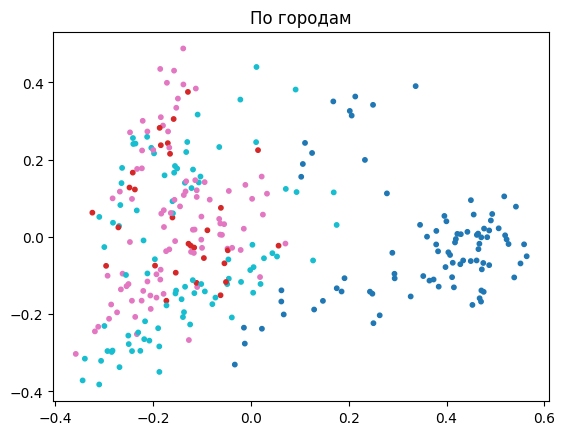

In [37]:
from sklearn.decomposition import PCA

X = np.array(embeddings_list)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)


plt.scatter(X_pca[:, 0], X_pca[:, 1], c=colors, s=10, cmap='tab10')
plt.title('По городам')
plt.show()

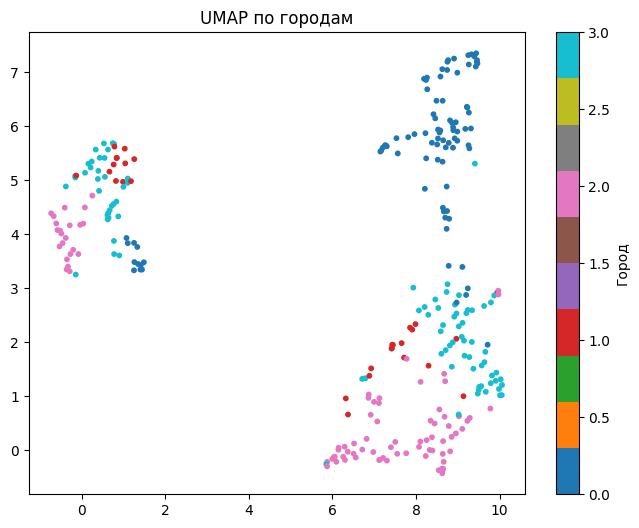

In [38]:
import umap
texts = [chunk.page_content for chunk in chunks]
X = np.array(embeddings.embed_documents(texts))

umap_model = umap.UMAP(n_components=2)
X_umap = umap_model.fit_transform(X)

plt.figure(figsize=(8, 6))
plt.scatter(X_umap[:, 0], X_umap[:, 1], c=colors, s=10, cmap='tab10')
plt.colorbar(label='Город')
plt.title('UMAP по городам')
plt.show()

In [39]:
#Теперь нужно добавить ЛЛМ, которая будет писать ответ

from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

quant_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16
)

model_answer_name = "Qwen/Qwen2.5-3B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(model_answer_name)
tokenizer.pad_token = tokenizer.eos_token

model_answer = AutoModelForCausalLM.from_pretrained(
    model_answer_name,
    torch_dtype=torch.float16,
    device_map="auto"
)

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [ ]:
#Выяснилось путём экспериментов, что у меня не получается вручить ллм выход 
# функции поиска и получить разумный ответ, как ни старайся. 
# Поэтому я напишу отдельную функцию, которая будет
# формировать промт из вопроса пользователя и данных выдачи

In [234]:
def make_prompt(data, question):
    main_res = data[0]
    other_res = data[1:]

    main_metadata = main_res['metadata']

    name = main_metadata['name']
    city = main_metadata['city']
    desc = main_metadata['description']
    wikidata = main_metadata['wikidata']
    lon = main_metadata['lon']
    lat = main_metadata['lat']
    city = main_metadata['city']
    
    main_context = f'''
    {name} находится в городе {city}. Это {desc}. Он расположен на широте {lat} и долготе {lon}.
    Более подробную информацию можно узнать на викидате, ID {name} - {wikidata}.
    '''
    
    other_data = []

    for x in other_res:
    
        name = x['metadata']['name']
        city = x['metadata']['city']
        info = f'''{name} в городе {city}
        '''
        other_data.append(info)
    
    other_context = ' '.join(other_data)

    result_promt = f'''
    <|im_start|>system
    Ты помощник туриста.
    <|im_end|>
    <|im_start|>user
    Контекст: {main_context}
    Дополнительные данные: {other_context}
    Вопрос: {question}

    Ответь на вопрос, используя только информацию из контекста. Сообщи естественным
    человеческим языком всё, что узнал
    из контекста об объекте, интересующем пользователя: название, город,
    широту, долготу, викидату. Ты должен говорить
    как человек, а не просто выдавать данные. Не придумывай
    информацию, которой нет в контексте. Списки строго запрещены.
    Если вопрос никак не связан с 
    контекстом, скажи "я не знаю". В конце ответа напиши с новой строки:
    "Также вас могут заинтересовать:"
    и сообщи обо всех объектах, которые перечислены в дополнительных данных
    <|im_end|>
    <|im_start|>assistant
    '''
    
    return result_promt, main_context, other_context

In [119]:
test_question = 'Есть ли в Екатеринбурге стадион?'
test_results = retrieve_and_rerank(test_question, k=3)
print(make_prompt(test_results, test_question))

100%|███████████████████████████████████████| 1/1 [00:00<00:00, 61.38it/s]


    <|im_start|>system
    Ты помощник туриста.
    <|im_end|>
    <|im_start|>user
    Контекст: 
    Центральный стадион находится в городе Екатеринбург. Это стадион в Екатеринбурге. Он расположен на широте 56.832283 и долготе 60.573955999999995.
    Более подробную информацию можно узнать на викидате, ID Центральный стадион - Q190779.
    
    Дополнительные данные: Усадьба Расторгуевых — Харитоновых в городе Екатеринбург
         Харитоновский сад в городе Екатеринбург
        
    Вопрос: Есть ли в Екатеринбурге стадион?

    Ответь на вопрос, используя только информацию из контекста. Сообщи естественным
    человеческим языком всё, что узнал
    из контекста об объекте, интересующем пользователя: название, город,
    широту, долготу, викидату. Ты должен говорить
    как человек, а не просто выдавать данные. Не придумывай
    информацию, которой нет в контексте. Если вопрос никак не связан с 
    контекстом, скажи "я не знаю". В конце ответа напиши с новой строки:
    "Также вас 

In [239]:
def get_answer(question, k=3):
    torch.cuda.empty_cache()
    results = retrieve_and_rerank(question, k=k)    
    prompt, main_context, other_context = make_prompt(results, question)
    
    inputs = tokenizer(prompt, return_tensors="pt").to(model_answer.device)
    outputs = model_answer.generate(
        **inputs,
        max_new_tokens=200,
        do_sample=True,
        temperature = 0.2,
        pad_token_id=tokenizer.eos_token_id
    )
    full_text = tokenizer.decode(outputs[0], skip_special_tokens=True)
   # results_out = [results[i]['content'] for i in range(len(results))]
    images = results[0]['metadata']['image'] 
   # context = '\n'.join(results_out)
    context = f'''
    Информация о самом релевантном объекте: {main_context}
    Дополнительно: {other_context}
    '''
    answer = full_text.split('assistant')[-1].strip()
    
    del inputs
    del outputs
    torch.cuda.empty_cache()
    
    return answer, context, images

/mnt/kurama/python/Akatsuki_Always/lib/python3.12/site-packages/colbert/utils/amp.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  return torch.cuda.amp.autocast() if self.activated else NullContextManager()
100%|███████████████████████████████████████| 1/1 [00:00<00:00, 59.25it/s]


Название храма в Екатеринбурге — Храм Вознесения Господня. Он находится в городе Екатеринбург. Его координаты — широта 56.84476099999999, долгота 60.612843. На викидатах храм имеет ID Q4500740.

    Также вас могут заинтересовать:
    Храм на Крови в городе Екатеринбург и храм Ярославской иконы Божией Матери в городе Ярославль.


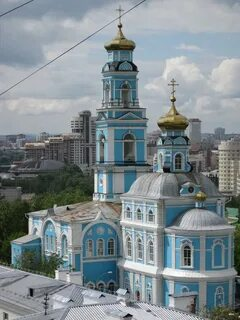

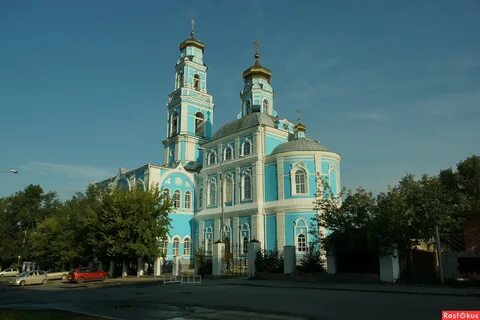

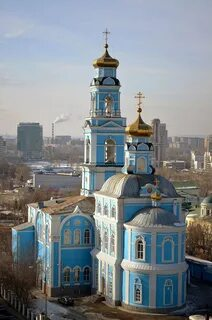

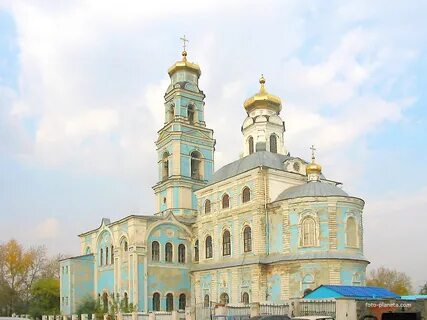

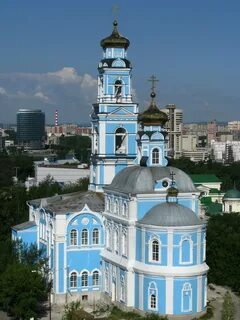

In [275]:
question = "Храм в екатеринбурге"
answer, context, images = get_answer(question)
print(answer)
# print()
# print(context)

for img in images[:5]:
    display(get_image(img))

In [85]:
#Как видно, всё отлично: модель пишет то, что и должна, не фантазирует,
# и прекрасно выводит картинки. 

# В промт подаётся контекст про этот стадион вот так:
# Центральный стадион находится в городе Екатеринбург. Это стадион в Екатеринбурге. 
# Он расположен на широте 56.832283 и долготе 60.573955999999995. А она не копирует
# что ей дали, а всё-таки перефразирует, что и должно быть

# RAGAS (3 балла)

RAGAS - это система, созданная для автоматической оценки эффективности модели RAG. Она представляет собой комплексный инструмент, способный оценить как качество извлечения информации, так и качество созданного текста. Это достигается благодаря использованию различных метрик, которые анализируют разные аспекты ответов, сгенерированных языковой моделью.



## Метрики оценки в RAGAS

### Faithfulness
Оценивает, насколько ответы языковой модели верно передают информацию, содержащуюся в источниках данных. Это критически важно, чтобы гарантировать, что модель не искажает или не меняет информацию при её интерпретации.

---

$
Faithfulness = \frac{\text{|Number of claims that can be inferred from given context|}}{\text{|Total number of claims in the generated answer|}}
$

### Answer Relevancy
Демонстрирует, насколько ответы соответствуют заданным вопросам. Это важный аспект, так как даже правильный ответ с технической точки зрения может быть ненужным, если он не отвечает на конкретный вопрос пользователя.

---

$\text{answer relevancy} = \frac{1}{N} \sum_{i=1}^{N} cos(E_{g_i}, E_o)$

$\text{answer relevancy} = \frac{1}{N} \sum_{i=1}^{N} \frac{E_{g_i} \cdot E_o}{\|E_{g_i}\|\|E_o\|}$

Где:

* $E_{g_i}$ - это эмбеддинг сгенерированного ответа $i$

* $E_o$ - это эмбеддинг исходного вопроса.

* $N$ - это количество сгенерированных вопросов, которое по умолчанию равно 3.

### Context Recall и Context Precision
Эти метрики измеряют эффективность модели в учете контекста вопроса для формирования ответа. "Context Recall" оценивает количество использованной информации из контекста в ответе, в то время как "Context Precision" оценивает точность и релевантность использования контекстной информации.

---

* $ \text{context recall} = \frac{\text{|GT sentences that can be attributed to context|}}{\text{|Number of sentences in GT|}} $
* $Context Precision@k = \frac{\sum \text{precision@k}}{\text{total number of relevant items in the top K results}}$
  * $Precision@k = \frac{\text {true positives@k}}{\text{(true positives@k + false positives@k)}}$

### Answer Semantic Similarity
Оценивает степень семантической близости между ответом модели и эталонным ответом. Это позволяет определить, насколько естественно и точно модель способна воссоздавать человеческий язык.

### Answer Correctness
Оценка корректности ответа. Это последний шаг в проверке, чтобы убедиться, предоставляет ли модель точную и достоверную информацию в своем ответе.

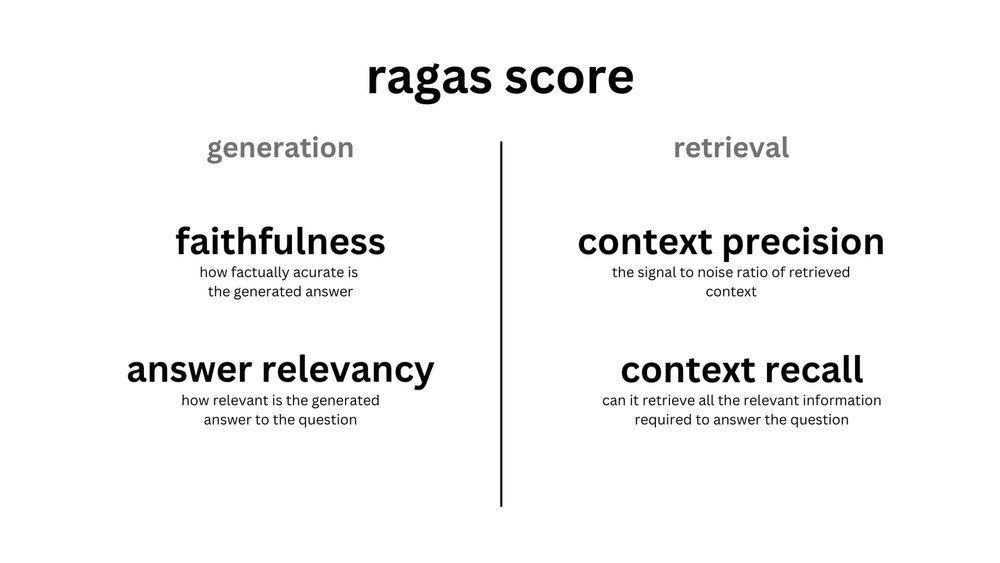

В этом задании вам нужно реализовать метрику answer_relevancy в коде. Опционально за допбаллы можно реализовать другие метрики.

Для этого датасет нужно привести к виду, в котором будут следующие поля:

### 1. question
- Смысл: Эта колонка содержит вопросы, на которые нужно найти ответы. В контексте задач QA, это основная информация, которую модель должна обработать для генерации ответа.
- Пример: "Каковы преимущества RAG?"

### 2. ground_truths
- Смысл: В этой колонке находятся правильные ответы на соответствующие вопросы. Это может использоваться для оценки производительности модели, так как позволяет сравнить сгенерированные ответы с эталонными.
- Пример: "RAG улучшает качество генерации, используя внешние источники информации."

### 3. answer
- Смысл: Эта колонка содержит ответы, которые генерирует модель на основе заданных вопросов. Это может быть результат работы модели, которую вы тестируете или обучаете.
- Пример: "RAG позволяет моделям извлекать информацию из внешних источников, что улучшает их способность отвечать на сложные вопросы."

### 4. contexts
- Смысл: Эта колонка предоставляет контекст или дополнительную информацию, которая может быть полезна для понимания вопроса или для формирования ответа. Это может быть текст, из которого был извлечен ответ, или другие релевантные документы.
- Пример: "RAG (Retrieval-Augmented Generation) — это метод, который использует внешние базы данных для получения информации при генерации текста."

HINT: Поле question можно тоже сгенерировать. Например, можно попросить модель задать вопрос по описанию изображения.

HINT: Для answer_relevancy нужны не все поля

HINT: Инференс такого эксперимента может быть долгим. План минимум: возьмите 100 случайных сэмплов.

In [ ]:
#Нам нужно сгенерировать 100 вопросов (я буду использовать чат "Алиса", у неё лучше
# всего получилось)

In [135]:
name_city_list = df[['Name', 'City']].values.tolist()
with open ('pairs_for_questions.txt', 'w', encoding='utf-8') as f:
    f.write(str(name_city_list))

In [ ]:
#Теперь Алиса на основании датасета уже сгенерировала 100 хороших вопросов. Можно 
# начинать формировать тестовый датасет

In [164]:
question_list = []
with open('questions_cleaned.txt', 'r', encoding='utf-8') as f:
    for line in f:
        if line!= '':
            question_list.append(line.strip())
print(len(question_list))

100


In [165]:
df_for_test = pd.DataFrame()
df_for_test['question'] = question_list
print(df_for_test.head())

                                                   question
0                              Где стоит Блиновский пассаж?
1              Где находится памятник 1000-летию Ярославля?
2        В каком месте расположен Храм Сергия Радонежского?
3  Где расположен Художественный Музей Эрнста Неизвестного?
4   В каком месте стоит церковь Иоанна Предтечи в Толчкове?


In [167]:
# Теперь я попросила Алису и ответить на эти вопросы, я просила отвечать максимально
# кратко, упоминая только географическое положение объекта. Алиса не захотела отвечать,
# указывая широту и долготу, она только давала адрес. Я просила такие короткие ответы,
# потому что у нашей модели тоже никакой нет информации кроме города и названия 
# объекта, так что иначе их будет невозможно сравнивать вообще. В процессе генерации
# ответов, оказалось, часть вопросов пришлось перегенерировать, они были неправильными

In [225]:
test_questions = []
perfect_answers = []

with open('answers_alisa.txt', 'r', encoding='utf-8-sig') as f:
    lines = f.readlines()

    for i in range(0, len(lines) - 1, 3):
        question = lines[i].strip()
        question = question.lstrip('\uFEFF\u200b\u00a0\t ')
        
        answer = lines[i+1].strip()
        answer = answer.lstrip('\uFEFF\u200b\u00a0\t ')
        
        test_questions.append(question)
        perfect_answers.append(answer)

In [226]:
pd.set_option("display.max_colwidth", 30)
print(df_for_test.info())
print(df_for_test.sample(10))

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   question      100 non-null    str  
 1   ground_truth  100 non-null    str  
dtypes: str(2)
memory usage: 24.6 KB
None
                         question                   ground_truth
83   Какой собор есть на Стрелке?  На Стрелке в Ярославле рас...
35  В каком месте стоит Толгск...  Толгский монастырь стоит в...
75  Где в Екатеринбурге стоит ...  Дома‑музея Столетовых в Ек...
68  В каком месте расположен х...  Храм Зосимы и Савватия рас...
34  Где расположен Центральный...  Центральный стадион Екатер...
91  Где находится Богородице‑Р...  Богородице‑Рождественский ...
57  Где находится церковь Рожд...  Церковь Рождества Иоанна П...
3   Где расположен Художествен...  Художественный Музей Эрнст...
28  В каком месте стоит Дмитри...  Дмитриевская башня стоит в...
11  Где расположен Ярославский...  Ярославский музей

In [ ]:
#Я не знаю откуда взялись эти пробелы в начале некоторых вопросов. Дипсик тоже не 
# знает. И Алиса. Поскольку они не мешают, пусть будут. Сформируем тем временем
# остальные колонки датафрейма для теста. В answer будет записываться ответ модели.
# А в contexts - контекст, который предоставлялся модели для ответа. То есть, то, что было 
# у неё в промте, а не всё, что выдаёт поисковая функция.

In [241]:
def make_dataframe(question):
    answer, context, images = get_answer(question)
    return pd.Series([answer, context])

df_for_test[['answer', 'context']] = df_for_test['question'].apply(make_dataframe)

/mnt/kurama/python/Akatsuki_Always/lib/python3.12/site-packages/colbert/utils/amp.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  return torch.cuda.amp.autocast() if self.activated else NullContextManager()
100%|███████████████████████████████████████| 1/1 [00:00<00:00, 52.54it/s]


In [243]:
df_for_test.sample(10)

,question,ground_truth,answer,context
7,Где находится Спасский ста...,Спасский староярмарочный с...,"Я не знаю, где находится С...",\n Информация о самом р...
15,В каком месте стоит Успенс...,Успенский Княгинин монасты...,"К сожалению, в предоставле...",\n Информация о самом р...
49,В каком месте расположен Х...,Храм на Крови расположен в...,Храм на Крови находится в ...,\n Информация о самом р...
76,В каком здании раньше была...,Гостиница «Мадрид» раньше ...,В здании бывшей гостиницы ...,\n Информация о самом р...
31,В каком месте стоит часовн...,Часовня Казанской Богомате...,Казанская церковь Казанско...,\n Информация о самом р...
10,Где находится Музей ложки?,Музей ложки находится в Вл...,Музей ложки находится в го...,\n Информация о самом р...
17,Где находится церковь Рожд...,Церковь Рождества Христова...,Церковь Рождества Христова...,\n Информация о самом р...
72,Где расположен Музей истор...,Музей истории Екатеринбург...,Музей истории Екатеринбург...,\n Информация о самом р...
23,Какой театр работает на ул...,На улице Горького (в Нижне...,"Театр оперы и балета, расп...",\n Информация о самом р...
18,В каком месте стоит Князь‑...,Князь‑Владимирский храм во...,Князь-Владимирский храм на...,\n Информация о самом р...


In [244]:
df_for_test.to_csv('test_df_dl2dz5.csv')

In [248]:
def data_preprocess(dataset):
    processed_data = []
    
    for item in dataset:
        question_emb = embeddings.embed_query(item['question'])  # на CPU
        answer_emb = embeddings.embed_query(item['model_answer'])  # на CPU
        
        processed_data.append({
            'question': item['question'],
            'model_answer': item['model_answer'],
            'question_emb': question_emb,
            'answer_emb': answer_emb
        })

    return processed_data


In [249]:
from sklearn.metrics.pairwise import cosine_similarity

def answer_relevancy(question_emb, answer_emb):
    q_emb = np.array(question_emb).reshape(1, -1)
    a_emb = np.array(answer_emb).reshape(1, -1)
    
    similarity = cosine_similarity(q_emb, a_emb)[0][0]
    return similarity

# Протестируйте ваш RAG (3 балла)

In [254]:
test_df_our_model = df_for_test[['question', 'answer']]
test_df_our_model.columns = ['question', 'model_answer']
print(test_df_our_model.head())

                        question                   model_answer
0   Где стоит Блиновский пассаж?  Блиновский пассаж находитс...
1  Где находится памятник 100...  Я не знаю, где находится п...
2  В каком месте расположен Х...  Храм Сергия Радонежского н...
3  Где расположен Художествен...  Художественный Музей Эрнст...
4  В каком месте стоит церков...  Я не знаю. \n\n     Так же...


In [257]:
dict_for_our_model = test_df_our_model.to_dict('records')
embedings_for_our_model = data_preprocess(dict_for_our_model)

In [263]:
relevancy_score_for_our_model = []

for item in embedings_for_our_model:
    score = answer_relevancy(item['question_emb'], item['answer_emb'])
    relevancy_score_for_our_model.append(score)

print(relevancy_score_for_our_model[:5])  
print(f"Средняя релевантность: {sum(relevancy_score_for_our_model)/len(relevancy_score_for_our_model):.3f}")

[0.53879794157209, 0.8414689072159737, 0.8251877289838738, 0.7826617270713729, 0.6725301261087215]
Средняя релевантность: 0.764


In [267]:
test_df_our_model['answer_relevancy'] = relevancy_score_for_our_model
print(test_df_our_model.head())

                        question                   model_answer  \
0   Где стоит Блиновский пассаж?  Блиновский пассаж находитс...   
1  Где находится памятник 100...  Я не знаю, где находится п...   
2  В каком месте расположен Х...  Храм Сергия Радонежского н...   
3  Где расположен Художествен...  Художественный Музей Эрнст...   
4  В каком месте стоит церков...  Я не знаю. \n\n     Так же...   

   answer_relevancy  
0          0.538798  
1          0.841469  
2          0.825188  
3          0.782662  
4          0.672530  


In [ ]:
# Заметно, что высокая релевантность не всегда соответствует тем ответам, где модель
# ответила правильно. Это связано с тем, что тут оценивается не правильность
# ответа, а его семантическую близость к вопросу. И если модель повторяет в своём "я не знаю"
# вопрос, метрика высокая. И наоборот, если ответ на вопрос есть, но сформулирован не 
# совсем так, как в вопросе, низкая

In [268]:
test_df_perfect_answers = df_for_test[['question', 'ground_truth']]
test_df_perfect_answers.columns = ['question', 'model_answer']
print(test_df_perfect_answers.head())

                        question                   model_answer
0   Где стоит Блиновский пассаж?  Блиновский пассаж находитс...
1  Где находится памятник 100...  Памятник 1000‑летию Яросла...
2  В каком месте расположен Х...  Храм Сергия Радонежского н...
3  Где расположен Художествен...  Художественный Музей Эрнст...
4  В каком месте стоит церков...  Церковь Иоанна Предтечи в ...


In [269]:
dict_for_perfect_answers = test_df_perfect_answers.to_dict('records')
embedings_for_perfect_answers = data_preprocess(dict_for_perfect_answers)

In [270]:
relevancy_score_for_perfect_answers = []

for item in embedings_for_perfect_answers:
    score = answer_relevancy(item['question_emb'], item['answer_emb'])
    relevancy_score_for_perfect_answers.append(score)

print(relevancy_score_for_perfect_answers[:5])  
print(f"Средняя релевантность: {sum(relevancy_score_for_perfect_answers)/len(relevancy_score_for_perfect_answers):.3f}")

[0.36479120070940363, 0.8141709372420778, 0.743072593138599, 0.6957146497559159, 0.6509427860506065]
Средняя релевантность: 0.709


In [271]:
test_df_perfect_answers['answer_relevancy'] = relevancy_score_for_perfect_answers
print(test_df_perfect_answers.head())

                        question                   model_answer  \
0   Где стоит Блиновский пассаж?  Блиновский пассаж находитс...   
1  Где находится памятник 100...  Памятник 1000‑летию Яросла...   
2  В каком месте расположен Х...  Храм Сергия Радонежского н...   
3  Где расположен Художествен...  Художественный Музей Эрнст...   
4  В каком месте стоит церков...  Церковь Иоанна Предтечи в ...   

   answer_relevancy  
0          0.364791  
1          0.814171  
2          0.743073  
3          0.695715  
4          0.650943  


In [ ]:
# Заметно, что идеальные ответы тоже оценились примерно так же. Даже немного ниже.

# Дополнительная часть (+3 балла)

Реализуйте одну из метрик retrieval-части на выбор.

Для того, чтобы понять model as a judge подход из RAGAS, советуем посетить [этот кукбук](https://huggingface.co/learn/cookbook/en/rag_evaluation)

In [ ]:
# Сначала подготовим всё тот же датасет: добавим в test_df_our_model столбик с контекстом.
# А оценивать будет та же модель, qwen2.5_3B. Потому что это учебное задание. И нет смысла
# загружать ещё одну модель для идеальной чистоты эксперимента

# Метрика будет context_recall, это должно быть проще

In [277]:
test_df_our_model['context'] = df_for_test['context']
test_df_our_model['context_recall'] = 0.0
test_df_our_model.to_csv('test_df_our_model_dl2dz5.csv')
test_df_our_model.head()

,question,model_answer,answer_relevancy,context,context_recall
0,Где стоит Блиновский пассаж?,Блиновский пассаж находитс...,0.538798,\n Информация о самом р...,0.0
1,Где находится памятник 100...,"Я не знаю, где находится п...",0.841469,\n Информация о самом р...,0.0
2,В каком месте расположен Х...,Храм Сергия Радонежского н...,0.825188,\n Информация о самом р...,0.0
3,Где расположен Художествен...,Художественный Музей Эрнст...,0.782662,\n Информация о самом р...,0.0
4,В каком месте стоит церков...,Я не знаю. \n\n Так же...,0.672530,\n Информация о самом р...,0.0


In [351]:
def make_promt_for_recall(model_answer, context):    

    result_promt = f'''
    <|im_start|>system
   Ты должен оценить, сколько данных из контекста было использовано в ответе.
    <|im_end|>
    <|im_start|>user
    Контекст: {context}
    Ответ для оценки: {model_answer}

    Оцени по шкале от 0 до 1, какая доля контекста была использовано в ответе для оценки.
    Если в ответе указаны все параметры объекта из контекста (название, город, широта,
    долгота, id викидата), а кроме того, после слов "Вас также может заинтересовать"
    перечислены все объекты, указанные в контексте после слова "Дополнительно", такой
    ответ считается полным. 
    Если в ответе сказано "я не знаю", но при этом упомянут первый объект из контекста
    и город (даже без широты, долготы, викидаты), а также перечислены все объекты, 
    указанные в контексте после слова "Дополнительно", такой ответ тоже считается полным
    
    СТРОГО ЗАПРЕЩЕНО писать что-либо кроме оценки. 

    Твой ответ - только оценка от 0 до 1. Ты должен оценить
    долю контекста в ответе и вернуть её.
    <|im_end|>
    <|im_start|>assistant
    '''
    
    return result_promt

In [342]:
def context_recall(context, answer, model=model_answer):
    
    prompt = make_promt_for_recall(answer, context)
    
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    outputs = model.generate(
        **inputs,
        max_new_tokens=10,
        do_sample=True,
        temperature=0.1,
        pad_token_id=tokenizer.eos_token_id
    )
    full_answer = tokenizer.decode(outputs[0], skip_special_tokens=True)
    answer = full_answer.split('assistant')[-1].strip()
    
    return answer

In [352]:
example = test_df_our_model.loc[0]
example_context = example['context']
example_answer = example['model_answer']

result = context_recall(example_context, example_answer)
torch.cuda.empty_cache()
result = float(result)
print(result)
print(example_context)
print()
print(example_answer)

0.8

    Информация о самом релевантном объекте: 
    Блиновский пассаж находится в городе Нижний Новгород. Это Блиновский пассаж. Он расположен на широте 56.32814 и долготе 43.988136.
    Более подробную информацию можно узнать на викидате, ID Блиновский пассаж - Q79494225.
    
    Дополнительно: Беседка на Волжской набережной в городе Ярославль
         Дом Болконского в городе Ярославль
        
    

Блиновский пассаж находится в городе Нижний Новгород. Его координаты - широта 56.32814, долгота 43.988136. Вы можете найти больше информации о нем на викидате с ID Q79494225. 

    Также вас могут заинтересовать:
    Беседка на Волжской набережной в городе Ярославль, Дом Болконского в городе Ярославль.


In [353]:
example = test_df_our_model.loc[1]
example_context = example['context']
example_answer = example['model_answer']

result = context_recall(example_context, example_answer)
torch.cuda.empty_cache()
result = float(result)
print(result)
print(example_context)
print()
print(example_answer)

0.5

    Информация о самом релевантном объекте: 
    Памятник Я.М. Свердлову находится в городе Екатеринбург. Это памятник в Екатеринбурге. Он расположен на широте 56.839813 и долготе 60.616417.
    Более подробную информацию можно узнать на викидате, ID Памятник Я.М. Свердлову - Q11823227.
    
    Дополнительно: Дом Сироткина в городе Нижний Новгород
         Обелиск Минину и Пожарскому в городе Нижний Новгород
        
    

Я не знаю, где находится памятник 1000-летию Ярославля по информации, которую мне предоставили. В контексте указаны только данные о памятнике Я.М. Свердлову в Екатеринбурге и обелиске Минину и Пожарскому в Нижнем Новгороде. 

    Также вас могут заинтересовать:
    Дом Сироткина в городе Нижний Новгород
    Обелиск Минину и Пожарскому в городе Нижний Новгород


In [345]:
#Запустив несколько раз ячейки выше, я увидела, что результаты получаются стабильно,
# с погрешностью примерно 0.05-0.1 при перегенерации. Это значит, что модель правильно
# поняла, что от неё требуется. Она ставит высокие оценки хорошему ответу и плохие 
# ответу, где информация не найдена. Это логично, потому что в ответах, где информация
# не найдена, модель не использует всю информацию из контекста, а напротив, пишет,
# что не нашла информацию о вопросе, как от неё и требовалось.

In [354]:
recall_scores = []

for idx, row in test_df_our_model.iterrows():
    score = context_recall(
        context=row['context'],
        answer=row['model_answer'],
        model=model_answer,  
    )
    recall_scores.append(score)

    torch.cuda.empty_cache()

In [361]:
test_df_our_model['context_recall'] = recall_scores
test_df_our_model['context_recall'] = test_df_our_model['context_recall'].astype(float)
print(test_df_our_model.head())
test_df_our_model.to_csv('test_df_our_model_full_dl2dz5.csv')

                        question                   model_answer  \
0   Где стоит Блиновский пассаж?  Блиновский пассаж находитс...   
1  Где находится памятник 100...  Я не знаю, где находится п...   
2  В каком месте расположен Х...  Храм Сергия Радонежского н...   
3  Где расположен Художествен...  Художественный Музей Эрнст...   
4  В каком месте стоит церков...  Я не знаю. \n\n     Так же...   

   answer_relevancy                        context  context_recall  
0          0.538798  \n    Информация о самом р...            0.80  
1          0.841469  \n    Информация о самом р...            0.50  
2          0.825188  \n    Информация о самом р...            1.00  
3          0.782662  \n    Информация о самом р...            0.75  
4          0.672530  \n    Информация о самом р...            0.00  


In [362]:
print(f'Средняя answer relevancy: {round(test_df_our_model['answer_relevancy'].mean(), 4)}')
print(f'Средняя context recall: {round(test_df_our_model['context_recall'].mean(), 4)}')

Средняя answer relevancy: 0.7638
Средняя context recall: 0.671
